In [1]:
# importing necessary libraries


import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

In [2]:
# Checking the current working directory
print(os.getcwd())

f:\dsproject\Telco_Customer_Churn\notebook


In [3]:
data_path = os.path.join("..", "data", "raw","telco_customer_churn.csv")

print(os.getcwd())

print(os.path.exists(data_path))

f:\dsproject\Telco_Customer_Churn\notebook
True


In [4]:
telco = pd.read_csv(data_path)

telco.head()

,Unnamed: 0,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
# Displaying the last 5 rows of the dataset
telco.tail()

,Unnamed: 0,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [6]:
# Displaying the shape of the data
telco.shape

(7043, 21)

In [7]:
# Displaying the information about the Telco data
telco.info

<bound method DataFrame.info of       Unnamed: 0  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  \
0              No  No phone service             DSL      

In [8]:
# SDisplaying the numerical statistics of the data
telco.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [9]:
# Checking the total missing data
telco.isna().sum()

Unnamed: 0          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [10]:
# Checking data duplicate
telco.duplicated().sum()

0

In [11]:
telco.nunique()

Unnamed: 0          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

In [12]:
# Adding a random sample of 5 rows to the dataset for better understanding

telco.sample(5, random_state=42)

,Unnamed: 0,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
185,1024-GUALD,Female,0,Yes,No,1,No,No phone service,DSL,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,24.80,24.8,Yes
2715,0484-JPBRU,Male,0,No,No,41,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer (automatic),25.25,996.45,No
3825,3620-EHIMZ,Female,0,Yes,Yes,52,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.35,1031.7,No
1807,6910-HADCM,Female,0,No,No,1,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,No,Electronic check,76.35,76.35,Yes
132,8587-XYZSF,Male,0,No,No,67,Yes,No,DSL,No,No,No,Yes,No,No,Two year,No,Bank transfer (automatic),50.55,3260.1,No


In [13]:
# Checking the data types
telco.dtypes

Unnamed: 0           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [14]:
# Creating a schema of the dataset

schema = pd.DataFrame({
    "column": telco.columns,
    "dtype": telco.dtypes.astype(str),
    "missing": telco.isna().sum().values,
    "unique": telco.nunique().values
})

schema

,column,dtype,missing,unique
Unnamed: 0,Unnamed: 0,object,0,7043
gender,gender,object,0,2
SeniorCitizen,SeniorCitizen,int64,0,2
Partner,Partner,object,0,2
Dependents,Dependents,object,0,2
tenure,tenure,int64,0,73
PhoneService,PhoneService,object,0,2
MultipleLines,MultipleLines,object,0,3
InternetService,InternetService,object,0,3
OnlineSecurity,OnlineSecurity,object,0,3


In [15]:
# Identifying numerical and categorical features

numerical_features = telco.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = telco.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges']

Categorical features:
['Unnamed: 0', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


In [16]:
# Checking the missing values in the dataset

missing_values = telco.isnull().sum()

missing_values[missing_values > 0]

Series([], dtype: int64)

In [17]:
# Checking the missing values in the dataset

missing_summary = pd.DataFrame({
    "missing_count": telco.isnull().sum(),
    "missing_percentage": telco.isnull().mean() * 100
})

missing_summary = missing_summary[
    missing_summary["missing_count"] > 0
].sort_values(
    "missing_percentage",
    ascending=False
)

missing_summary

,missing_count,missing_percentage


In [18]:
# Checking blank string in the data

(telco == " ").sum()

Unnamed: 0           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [19]:
# Checking the value counts for the "TotalCharges" column, including NaN values
telco["TotalCharges"].value_counts(dropna=False).head()

TotalCharges
         11
20.2     11
19.75     9
20.05     8
19.9      8
Name: count, dtype: int64

In [20]:
#  Checking the number of blank values in the "TotalCharges" column
blank_total_charges = (telco["TotalCharges"] == " ").sum()

print(f"Blank TotalCharges values: {blank_total_charges}")

Blank TotalCharges values: 11


In [21]:
# Checking the number of duplicate rows in the dataset

duplicate_count = telco.duplicated().sum()

print(f"Duplicate rows: {duplicate_count}")

Duplicate rows: 0


In [22]:
# Checking the duplicated sets in the data
telco[telco.duplicated()]

,Unnamed: 0,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [23]:
# Checking of the data
len(telco)

7043

Descriptive Statistics

In [24]:
telco.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [25]:
telco.describe(include="object").T

,count,unique,top,freq
Unnamed: 0,7043,7043,7590-VHVEG,1
gender,7043,2,Male,3555
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095


In [26]:
# cardinality analysis
cardinality = (
    telco.nunique()
    .sort_values(ascending=False)
    .to_frame("unique_values")
)

cardinality

,unique_values
Unnamed: 0,7043
TotalCharges,6531
MonthlyCharges,1585
tenure,73
PaymentMethod,4
DeviceProtection,3
Contract,3
StreamingMovies,3
StreamingTV,3
TechSupport,3


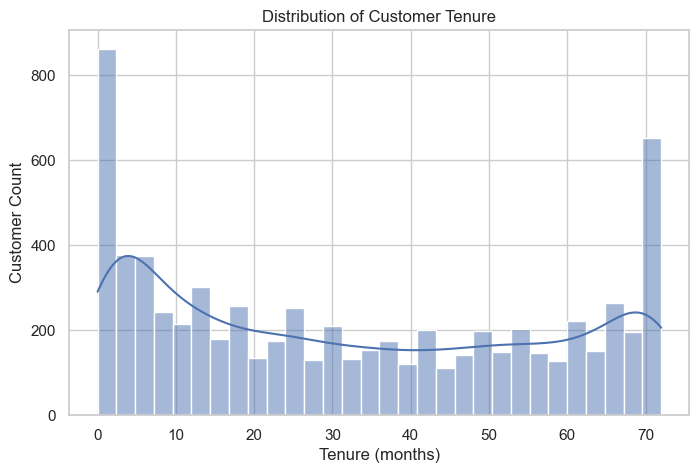

In [27]:
# Displaying the plot for "tenure"
plt.figure(figsize=(8, 5))

sns.histplot(
    data=telco,
    x="tenure",
    bins=30,
    kde=True
)

plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (months)")
plt.ylabel("Customer Count")
plt.show()

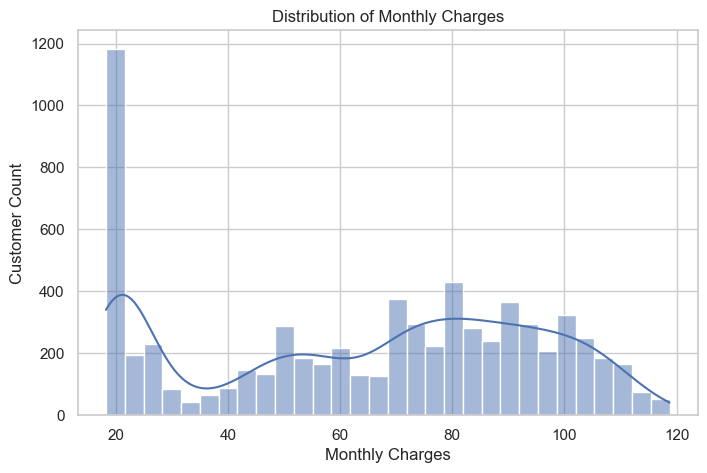

In [28]:
# Monthly Charges
plt.figure(figsize=(8, 5))

sns.histplot(
    data=telco,
    x="MonthlyCharges",
    bins=30,
    kde=True
)

plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Customer Count")
plt.show()

In [29]:
telco["TotalCharges"] = pd.to_numeric(
    telco["TotalCharges"],
    errors="coerce"
)

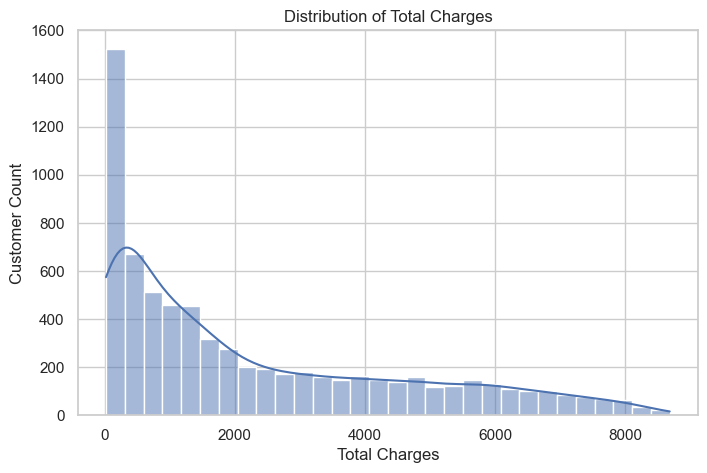

In [30]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=telco,
    x="TotalCharges",
    bins=30,
    kde=True
)

plt.title("Distribution of Total Charges")
plt.xlabel("Total Charges")
plt.ylabel("Customer Count")
plt.show()

Categorical

In [31]:
categorical_columns = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "PhoneService",
    "InternetService",
    "Contract",
    "PaymentMethod"
]

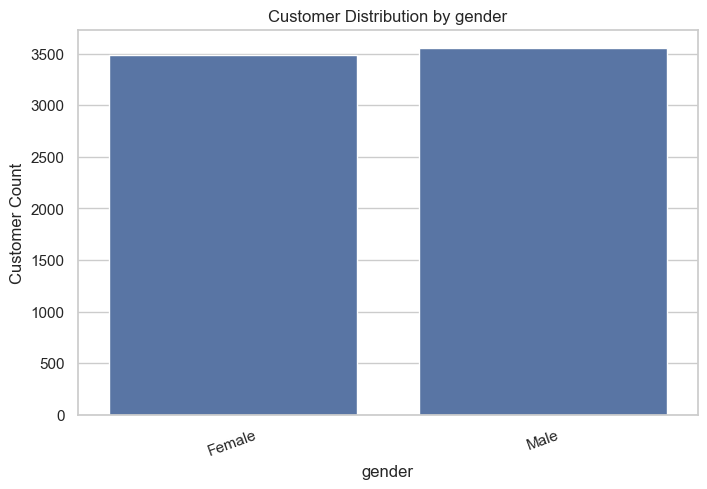

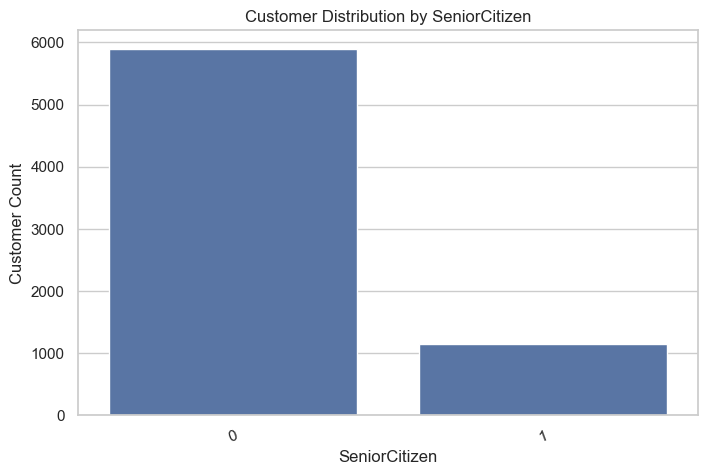

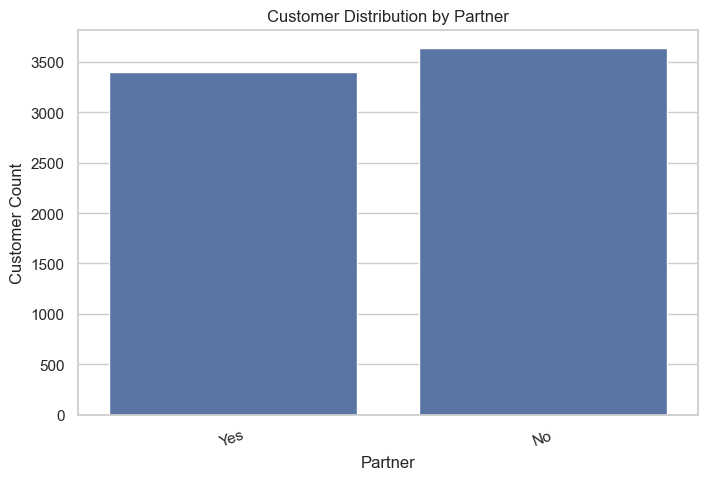

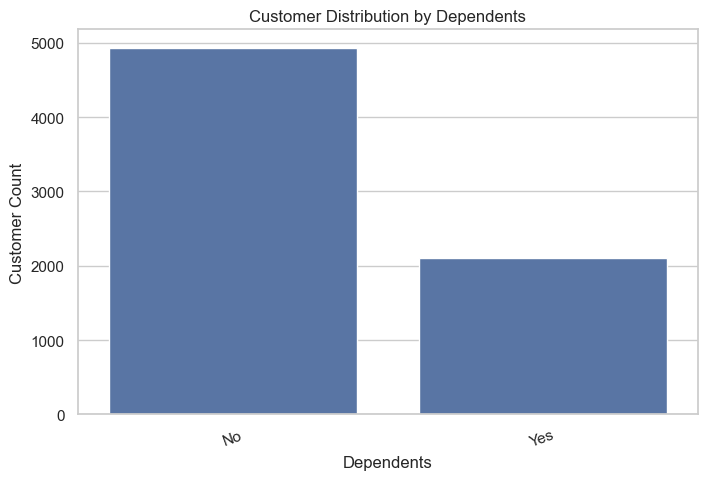

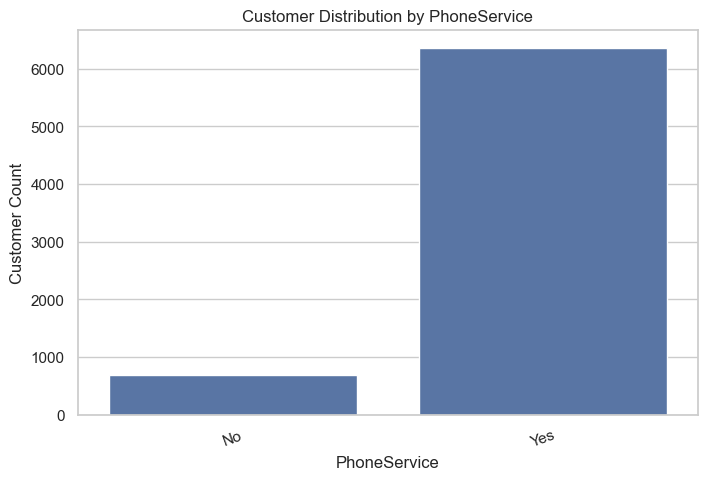

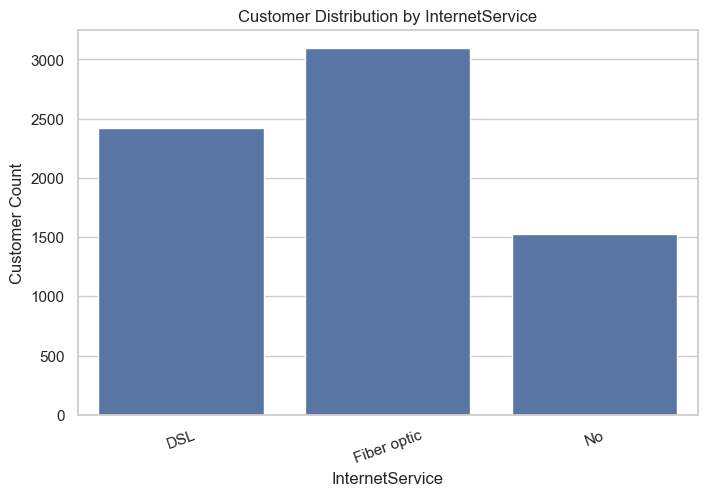

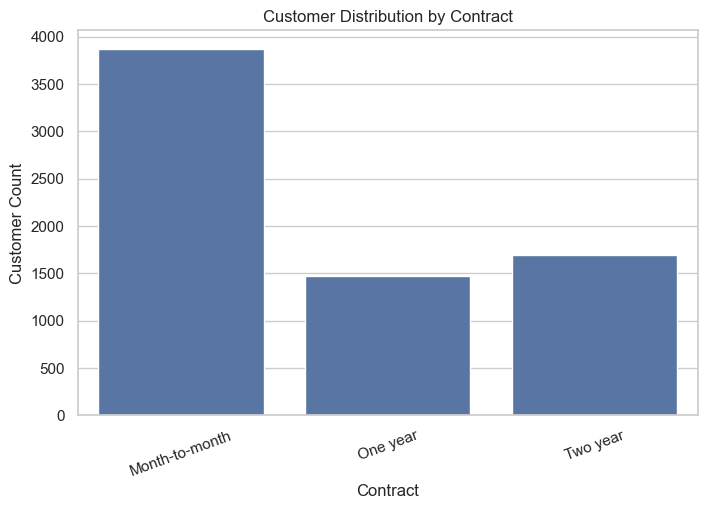

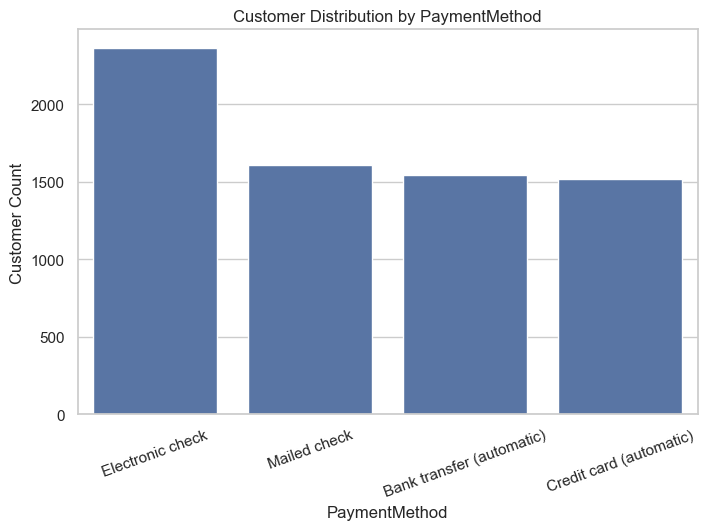

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

In [32]:
# Displaying the count plots for categorical features
for column in categorical_columns:
    plt.figure(figsize=(8, 5))
    
    sns.countplot(
        data=telco,
        x=column
    )
    
    plt.title(f"Customer Distribution by {column}")
    plt.xlabel(column)
    plt.ylabel("Customer Count")
    plt.xticks(rotation=20)
    plt.show()
plt.figure(figsize=(8, 5))



# Churn Distribution

In [33]:
# Displaying the count plot for the "Churn" column
telco["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [34]:
# Churn distribution
churn_distribution = (
    telco["Churn"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

churn_distribution

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

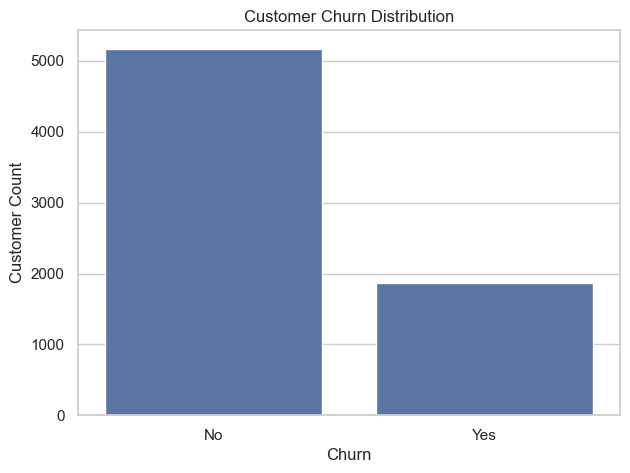

In [35]:
# Displaying the count plot for the "Churn" column
plt.figure(figsize=(7, 5))

sns.countplot(
    data=telco,
    x="Churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Customer Count")
plt.show()

# Churn analysis by categorical variables ⭐⭐⭐

In [36]:
# 
churn_by_contract = pd.crosstab(
    telco["Contract"],
    telco["Churn"],
    normalize="index"
) * 100

churn_by_contract

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


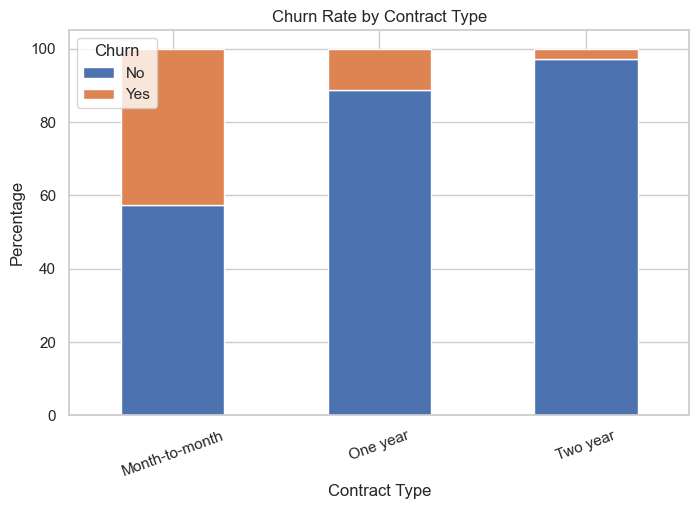

In [37]:
churn_by_contract.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage")
plt.legend(title="Churn")
plt.xticks(rotation=20)
plt.show()

# Analyze the most important categorical variables

In [38]:
# 
def churn_rate_by_column(telco, column):
    return (
        pd.crosstab(
            telco[column],
            telco["Churn"],
            normalize="index"
        )["Yes"]
        .sort_values(ascending=False)
        .mul(100)
        .round(2)
    )

In [39]:
churn_rate_by_column(telco, "Contract")

Contract
Month-to-month    42.71
One year          11.27
Two year           2.83
Name: Yes, dtype: float64

In [40]:
churn_rate_by_column(telco, "InternetService")

InternetService
Fiber optic    41.89
DSL            18.96
No              7.40
Name: Yes, dtype: float64

In [41]:
churn_rate_by_column(telco, "PaymentMethod")

PaymentMethod
Electronic check             45.29
Mailed check                 19.11
Bank transfer (automatic)    16.71
Credit card (automatic)      15.24
Name: Yes, dtype: float64

# Churn vs numerical variables

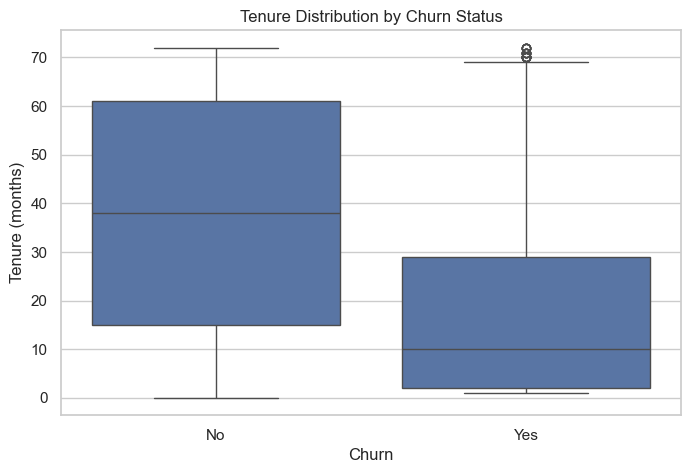

In [42]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=telco,
    x="Churn",
    y="tenure"
)

plt.title("Tenure Distribution by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Tenure (months)")
plt.show()

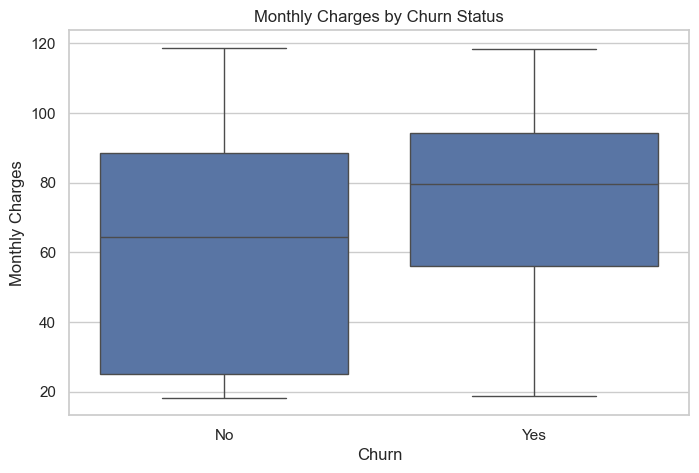

In [43]:
# Month

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=telco,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

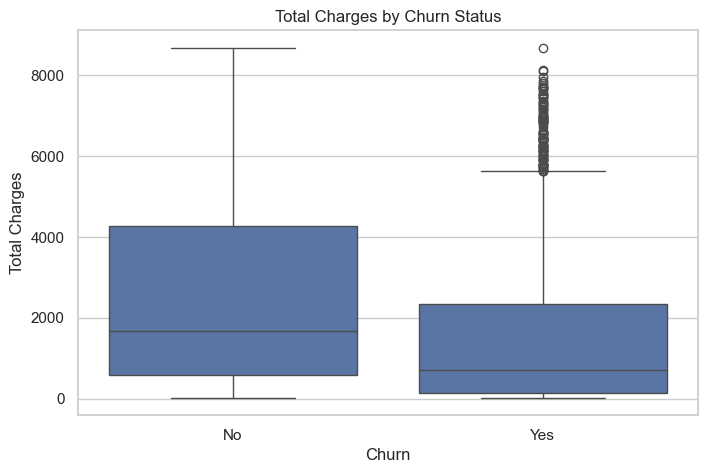

In [44]:
# Total Charges

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=telco,
    x="Churn",
    y="TotalCharges"
)

plt.title("Total Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Total Charges")
plt.show()

# Correlation analysis

In [45]:
numeric_telco = telco.select_dtypes(
    include=["int64", "float64"]
)

correlation = numeric_telco.corr()

correlation

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.016567,0.220173,0.102411
tenure,0.016567,1.000000,0.247900,0.825880
MonthlyCharges,0.220173,0.247900,1.000000,0.651065
TotalCharges,0.102411,0.825880,0.651065,1.000000


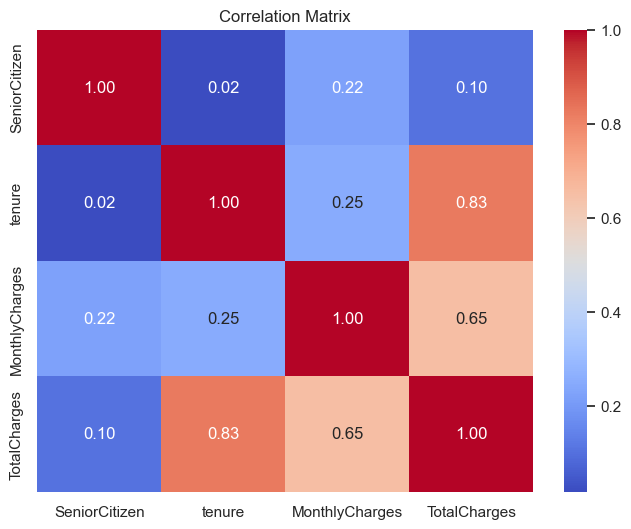

In [46]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

# Investigate relationships between important variables

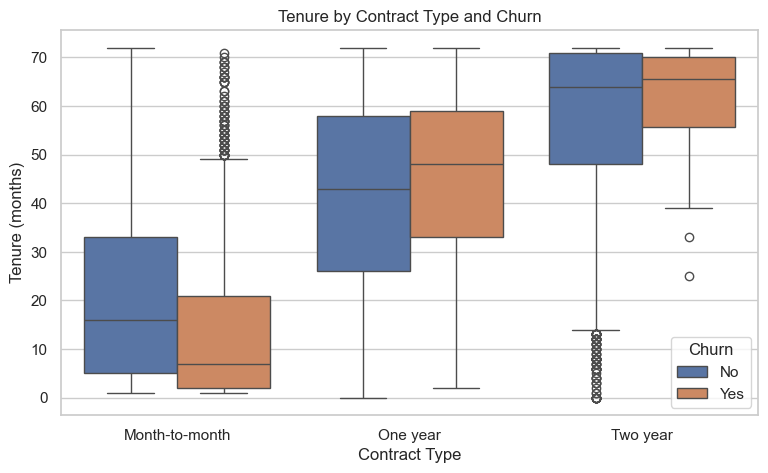

In [47]:
# Contract + Tenure + Churn
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=telco,
    x="Contract",
    y="tenure",
    hue="Churn"
)

plt.title("Tenure by Contract Type and Churn")
plt.xlabel("Contract Type")
plt.ylabel("Tenure (months)")
plt.show()

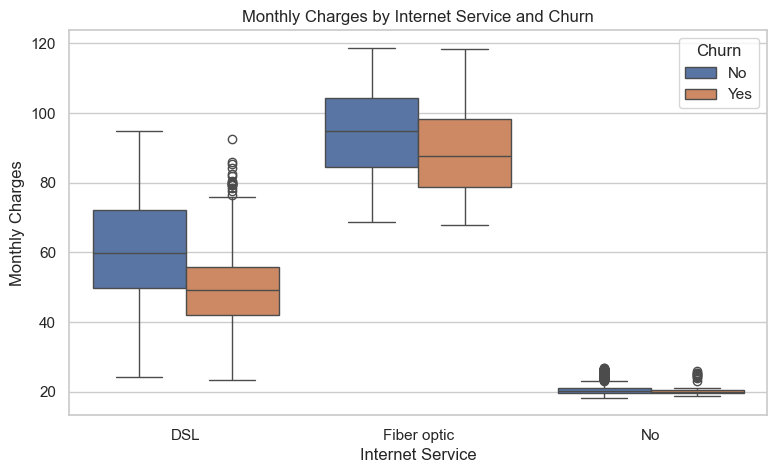

In [48]:
# Internet Service + Monthly Charges + Churn
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=telco,
    x="InternetService",
    y="MonthlyCharges",
    hue="Churn"
)

plt.title("Monthly Charges by Internet Service and Churn")
plt.xlabel("Internet Service")
plt.ylabel("Monthly Charges")
plt.show()

# Investigating suspicious values

In [49]:
print(telco["tenure"].min())
print(telco["tenure"].max())

0
72


In [50]:
print(telco["MonthlyCharges"].min())
print(telco["MonthlyCharges"].max())

18.25
118.75


In [51]:
for column in categorical_features:
    print(f"\n{column}:")
    print(sorted(telco[column].dropna().unique()))


Unnamed: 0:
['0002-ORFBO', '0003-MKNFE', '0004-TLHLJ', '0011-IGKFF', '0013-EXCHZ', '0013-MHZWF', '0013-SMEOE', '0014-BMAQU', '0015-UOCOJ', '0016-QLJIS', '0017-DINOC', '0017-IUDMW', '0018-NYROU', '0019-EFAEP', '0019-GFNTW', '0020-INWCK', '0020-JDNXP', '0021-IKXGC', '0022-TCJCI', '0023-HGHWL', '0023-UYUPN', '0023-XUOPT', '0027-KWYKW', '0030-FNXPP', '0031-PVLZI', '0032-PGELS', '0036-IHMOT', '0040-HALCW', '0042-JVWOJ', '0042-RLHYP', '0048-LUMLS', '0048-PIHNL', '0052-DCKON', '0052-YNYOT', '0056-EPFBG', '0057-QBUQH', '0058-EVZWM', '0060-FUALY', '0064-SUDOG', '0064-YIJGF', '0067-DKWBL', '0068-FIGTF', '0071-NDAFP', '0074-HDKDG', '0076-LVEPS', '0078-XZMHT', '0080-EMYVY', '0080-OROZO', '0082-LDZUE', '0082-OQIQY', '0083-PIVIK', '0089-IIQKO', '0093-EXYQL', '0093-XWZFY', '0094-OIFMO', '0096-BXERS', '0096-FCPUF', '0098-BOWSO', '0100-DUVFC', '0103-CSITQ', '0104-PPXDV', '0106-GHRQR', '0106-UGRDO', '0107-WESLM', '0107-YHINA', '0111-KLBQG', '0112-QAWRZ', '0112-QWPNC', '0114-IGABW', '0114-PEGZZ', '0114-

In [52]:
telco[telco["tenure"] == 0][
    ["tenure", "MonthlyCharges", "TotalCharges", "Churn"]
]

,tenure,MonthlyCharges,TotalCharges,Churn
488,0,52.55,NaN,No
753,0,20.25,NaN,No
936,0,80.85,NaN,No
1082,0,25.75,NaN,No
1340,0,56.05,NaN,No
3331,0,19.85,NaN,No
3826,0,25.35,NaN,No
4380,0,20.00,NaN,No
5218,0,19.70,NaN,No
6670,0,73.35,NaN,No


# Churn summary table ⭐

In [53]:
summary = pd.DataFrame({
    "metric": [
        "Total customers",
        "Total features",
        "Churned customers",
        "Non-churned customers",
        "Churn rate"
    ],
    "value": [
        len(telco),
        telco.shape[1],
        (telco["Churn"] == "Yes").sum(),
        (telco["Churn"] == "No").sum(),
        f"{(telco['Churn'] == 'Yes').mean() * 100:.2f}%"
    ]
})

summary

,metric,value
0,Total customers,7043
1,Total features,21
2,Churned customers,1869
3,Non-churned customers,5174
4,Churn rate,26.54%


# EDA Summary & Findings

This section consolidates the key outcomes of the exploratory data analysis and outlines their implications for the churn modeling phase.

---

## 1. Dataset Overview

- **Observations:** 7,043 customer records
- **Features:** 21 attributes, comprising customer demographics, account information, service subscriptions, and billing details
- **Target variable:** `Churn` (binary: Yes / No)
- **Observed churn rate:** ~26.5%, indicating a moderately imbalanced classification problem

## 2. Data Quality Assessment

- **Missing values:** No explicit nulls detected; however, `TotalCharges` contains **11 blank string entries** (corresponding to customers with `tenure = 0`), which were coerced to `NaN` upon numeric conversion
- **Duplicates:** No duplicate records identified
- **Type inconsistencies:** `TotalCharges` is stored as `object` and must be cast to numeric
- **Anomalous values:** The 11 records with `tenure = 0` are consistent with newly onboarded customers and require an explicit imputation strategy (e.g., zero-fill or exclusion)

## 3. Key Behavioral Insights

- **Contract type** is the strongest categorical churn driver: month-to-month contracts churn at ~43%, compared to ~11% for one-year and ~3% for two-year contracts
- **Tenure** exhibits a strong inverse relationship with churn — early-tenure customers represent the highest-risk segment
- **Monthly charges:** churned customers pay higher monthly charges on average, suggesting price sensitivity
- **Internet service:** fiber optic customers churn at a markedly higher rate (~42%) than DSL customers (~19%)
- **Payment method:** customers paying by electronic check show the highest churn rate (~45%)

## 4. Modeling Implications

- **Class imbalance:** Apply stratified train/test splitting; consider `class_weight` adjustments or resampling (e.g., SMOTE), and evaluate using precision/recall, F1, and ROC-AUC rather than accuracy alone
- **Feature removal:** Drop `customerID` (non-informative identifier)
- **Type conversion:** Convert `TotalCharges` to numeric and impute the 11 missing values
- **Encoding:** Binary-encode Yes/No fields; one-hot encode multi-category features (`Contract`, `InternetService`, `PaymentMethod`)
- **Scaling:** Standardize numerical features (`tenure`, `MonthlyCharges`, `TotalCharges`) for distance- and regularization-based models
- **Leakage review:** No obvious target leakage identified; `TotalCharges` is partially derived from `tenure × MonthlyCharges` but remains a legitimate predictor
